In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import matplotlib.pyplot as plt

In [4]:
# Downloading and Preparing the Dataset

# if have not downloaded dataset uncomment and use this
# (x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# x_train, x_test = x_train / 255.0, x_test / 255.0

# num_classes = 10
# y_train = tf.keras.utils.to_categorical(y_train, num_classes)
# y_test  = tf.keras.utils.to_categorical(y_test , num_classes)

import pickle
import numpy as np
import os

def load_cifar10_batch(file_path):
    with open(file_path, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
    data = batch[b'data']
    labels = batch[b'labels']
    # تبدیل از (N, 3072) به (N, 32, 32, 3)
    data = data.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    return data, np.array(labels)

def load_cifar10(root='./data'):
    base_path = os.path.join(root, 'cifar-10-batches-py')
    
    # داده‌های آموزش
    x_train_list = []
    y_train_list = []
    for i in range(1, 6):
        file_path = os.path.join(base_path, f'data_batch_{i}')
        data, labels = load_cifar10_batch(file_path)
        x_train_list.append(data)
        y_train_list.append(labels)
    
    x_train = np.concatenate(x_train_list)
    y_train = np.concatenate(y_train_list)
    
    # داده‌های تست
    test_file = os.path.join(base_path, 'test_batch')
    x_test, y_test = load_cifar10_batch(test_file)
    
    return (x_train, y_train), (x_test, y_test)

# استفاده از فایل‌های محلی
(x_train, y_train), (x_test, y_test) = load_cifar10(root='./data')

# نرمال‌سازی و one-hot encoding
x_train, x_test = x_train / 255.0, x_test / 255.0
num_classes = 10
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

In [6]:
#  Building the CNN Model

model = models.Sequential([
    
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,178 (1.22 MB)

 Trainable params: 319,178 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Compiling and Training the Model

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    epochs=15,
                    batch_size=64,
                    validation_split=0.2,
                    verbose=2)

Epoch 1/15
625/625 - 23s - 37ms/step - accuracy: 0.4459 - loss: 1.5231 - val_accuracy: 0.5636 - val_loss: 1.2533
Epoch 2/15
625/625 - 21s - 34ms/step - accuracy: 0.6027 - loss: 1.1231 - val_accuracy: 0.6113 - val_loss: 1.0957
Epoch 3/15
625/625 - 22s - 35ms/step - accuracy: 0.6631 - loss: 0.9584 - val_accuracy: 0.6685 - val_loss: 0.9531
Epoch 4/15
625/625 - 22s - 35ms/step - accuracy: 0.7034 - loss: 0.8475 - val_accuracy: 0.6883 - val_loss: 0.8946
Epoch 5/15
625/625 - 21s - 34ms/step - accuracy: 0.7343 - loss: 0.7612 - val_accuracy: 0.6892 - val_loss: 0.8889
Epoch 6/15
625/625 - 23s - 37ms/step - accuracy: 0.7590 - loss: 0.6876 - val_accuracy: 0.7078 - val_loss: 0.8609
Epoch 7/15
625/625 - 21s - 34ms/step - accuracy: 0.7813 - loss: 0.6212 - val_accuracy: 0.7141 - val_loss: 0.8388
Epoch 8/15
625/625 - 22s - 35ms/step - accuracy: 0.8039 - loss: 0.5579 - val_accuracy: 0.7130 - val_loss: 0.8756
Epoch 9/15
625/625 - 22s - 35ms/step - accuracy: 0.8225 - loss: 0.5002 - val_accuracy: 0.7197 - 

In [8]:
# Evaluating the Model

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print(f"Test accuracy = {test_acc:.3f}")

Test accuracy = 0.693


In [9]:
# Making Predictions

predictions = model.predict(x_test)

import numpy as np

# Example: predicting first test image
print("Predicted class:", np.argmax(predictions[0]))
print("Actual class:", np.argmax(y_test[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Predicted class: 3
Actual class: 3


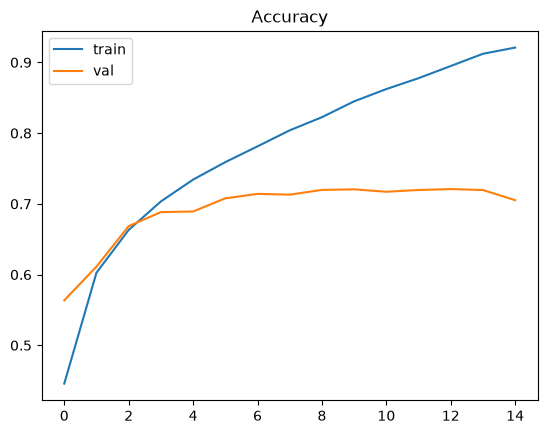

In [10]:
# Plotting of Accuracy Curves

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title('Accuracy')
plt.show()